## Тема занятия: пакетная нормализация в обучении нейронных сетей (Батч-нормализация)

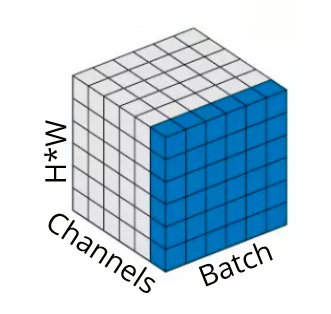

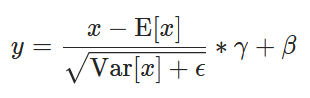

Внутренний ковариационный сдвиг — серьёзная проблема, с которой сталкиваются при обучении моделей глубокого обучения. Пакетная нормализация была введена для решения этой проблемы.

Пакетная нормализация была введена для смягчения проблемы внутреннего ковариационного сдвига в нейронных сетях Сергеем Иоффе и Кристианом Сегеди в 2015 году. Процесс нормализации включает вычисление среднего значения и дисперсии каждого признака в мини-пакете, а затем масштабирование и сдвиг признаков с использованием этой статистики. Это гарантирует, что входные данные для каждого слоя остаются примерно в том же распределении, независимо от изменений в распределении выходных данных более ранних слоёв. Следовательно, пакетная нормализация помогает стабилизировать процесс обучения, обеспечивая более высокую скорость обучения и более быструю сходимость.

**Необходимость в батч-нормализации**
Пакетная нормализация — это расширение концепции нормализации от входного слоя до активаций каждого скрытого слоя по всей нейронной сети. 

В традиционных нейронных сетях по мере распространения входных данных по сети распределение входов каждого слоя меняется. Это явление, известное как внутренний ковариационный сдвиг может замедлить процесс обучения (или даже препятствовать сходимости сети во время обучения). Пакетная нормализация направлена на смягчение этой проблемы путём нормализации входных данных каждого слоя. 

Входными данными для каждого скрытого слоя являются выходные данные предыдущего слоя. Если эти выходные данные нормализованы, это гарантирует, что сеть постоянно получает входные данные с одинаковым распределением, независимо от этапа обучения. Такая стабильность распределения входных данных обеспечивает более плавное и эффективное обучение.

При применении пакетной нормализации к скрытым слоям сети градиенты, распространяющиеся во время обратного распространения ошибки, с меньшей вероятностью будут исчезать или увеличиваться, что приводит к более стабильной динамике обучения. В конечном итоге это способствует более быстрой сходимости и повышению производительности нейронной сети при выполнении заданной задачи.

Будем использовать код из предыдущего занятия.<br>
Изменим архитектуру : добавим **батч-нормализацию** (torch.nn.BatchNorm2d)

In [ ]:
import torch
import random
import numpy as np

random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
torch.cuda.manual_seed(0)
torch.backends.cudnn.deterministic = True

In [ ]:
import torchvision.datasets

In [ ]:
MNIST_train = torchvision.datasets.MNIST('./', download=False, train=True)
MNIST_test = torchvision.datasets.MNIST('./', download=False, train=False)


In [ ]:
X_train = MNIST_train.data
y_train = MNIST_train.targets
X_test = MNIST_test.data
y_test = MNIST_test.targets

In [ ]:
len(y_train), len(y_test)

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(X_train[10, :, :])
plt.gray()
plt.show()
print(y_train[10])

In [ ]:
X_train = X_train.unsqueeze(1).float()
X_test = X_test.unsqueeze(1).float()

In [ ]:
X_train.shape

In [ ]:
class LeNet5(torch.nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()

        self.conv1 = torch.nn.Conv2d(
            in_channels=1, out_channels=6, kernel_size=5, padding=2)
        self.act1  = torch.nn.Tanh()
        self.pool1 = torch.nn.AvgPool2d(kernel_size=2, stride=2)

        self.conv2 = torch.nn.Conv2d(
            in_channels=6, out_channels=16, kernel_size=5, padding=0)
        self.act2  = torch.nn.Tanh()
        self.pool2 = torch.nn.AvgPool2d(kernel_size=2, stride=2)

        self.fc1   = torch.nn.Linear(5 * 5 * 16, 120)
        self.act3  = torch.nn.Tanh()

        self.fc2   = torch.nn.Linear(120, 84)
        self.act4  = torch.nn.Tanh()

        self.fc3   = torch.nn.Linear(84, 10)



    def forward(self, x):

        x = self.conv1(x)
        x = self.act1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.act2(x)
        x = self.pool2(x)

        x = x.view(x.size(0), x.size(1) * x.size(2) * x.size(3))

        x = self.fc1(x)
        x = self.act3(x)
        x = self.fc2(x)
        x = self.act4(x)
        x = self.fc3(x)

        return x

lenet5 = LeNet5()

In [ ]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
lenet5 = lenet5.to(device)

In [ ]:
loss = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(lenet5.parameters(), lr=1.0e-3)

In [ ]:
batch_size = 100

test_accuracy_history = []
test_loss_history = []

X_test = X_test.to(device)
y_test = y_test.to(device)

for epoch in range(10000):
    order = np.random.permutation(len(X_train))
    for start_index in range(0, len(X_train), batch_size):
        optimizer.zero_grad()

        batch_indexes = order[start_index:start_index+batch_size]

        X_batch = X_train[batch_indexes].to(device)
        y_batch = y_train[batch_indexes].to(device)

        preds = lenet5.forward(X_batch)

        loss_value = loss(preds, y_batch)
        loss_value.backward()

        optimizer.step()

    test_preds = lenet5.forward(X_test)
    test_loss_history.append(loss(test_preds, y_test).data.cpu())

    accuracy = (test_preds.argmax(dim=1) == y_test).float().mean().data.cpu()
    test_accuracy_history.append(accuracy)

    print(accuracy)

In [ ]:
lenet5.forward(X_test)

In [ ]:
plt.plot(test_accuracy_history);
# plt.plot(test_loss_history);

## Задание 1

Провести исследование влияния гиперпараметров на сходимость икачесвто сети при обучении на MNIST
1. Функции activation = 'tanh', 'relu'
2. Вид пуллинга    pooling = 'avg','max'
3. Свертки  conv_size  = 5, каскад сверток conv_size  = 3
4. Слой batch_normalization
5. Логгировать обучение с помощью TensorBoard.

In [ ]:
#ваш код

## Задание 2

Обучить вашу нейронную сеть на датасете Cifar10

In [ ]:
CIFAR_train = torchvision.datasets.CIFAR10('./', download=True, train=True)
CIFAR_test = torchvision.datasets.CIFAR10('./', download=True, train=False)

In [ ]:
X_train = torch.FloatTensor(CIFAR_train.data)
y_train = torch.LongTensor(CIFAR_train.targets)
X_test = torch.FloatTensor(CIFAR_test.data)
y_test = torch.LongTensor(CIFAR_test.targets)

In [ ]:
CIFAR_train.classes

In [ ]:
CIFAR_train.class_to_idx

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
figure(figsize = (8,8), dpi =20)
plt.imshow(X_train[1000, :, :])
print(y_train[1000])

In [ ]:
# размерность тензора [N C W H]

In [ ]:
X_train.shape